In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

In [2]:
mode = 'BandRemoval:2'
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_bandremoval_2 D:/DeepSSFP/block_phantom_dataset.npy


Saved dataset found. Loading from file: D:/DeepSSFP/block_phantom_dataset.npy


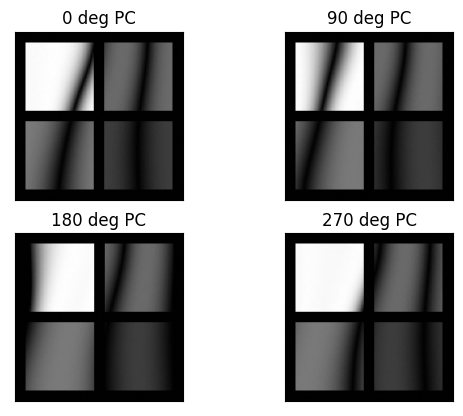

(160, 128, 128, 4) (160, 128, 128, 2)
-0.008195200336117937 0.1000156169921637 -0.009491002499543261 0.07863017274655343
Selected indices: [16 11 32]
Figure size: (6, 6)


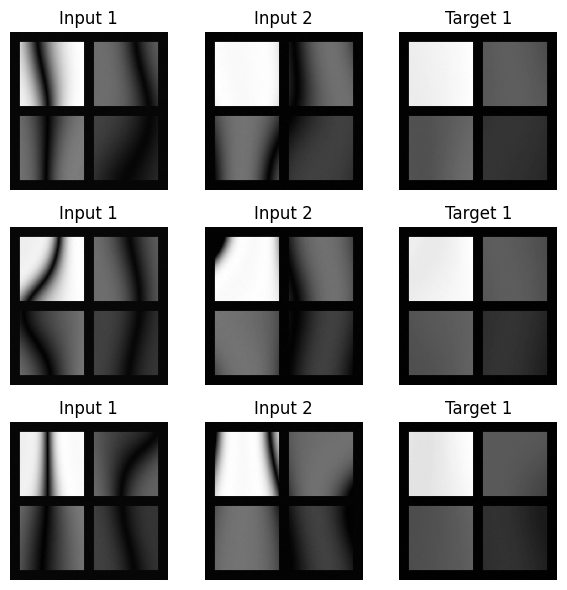

In [3]:
if(os.path.isfile(ds_path)):
    print(f'Saved dataset found. Loading from file: {ds_path}')
    dataset = np.load(ds_path, allow_pickle=True)[0]
else:
    slices = 200
    dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                          npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                          useRotate=True, useDeform=True)
    np.save(ds_path, [dataset])

data = dataset['M']
data.shape
mssfp.plot_dataset(data, slice=0)
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=3
)

In [4]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=False
)

2025-03-21 19:33:02,144 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_bandremoval_2
2025-03-21 19:33:02,145 - DeepSSFP - INFO - Training DataSet: (160, 128, 128, 4) | (160, 128, 128, 2)
2025-03-21 19:33:02,146 - DeepSSFP - INFO - Test DataSet: (40, 128, 128, 4) | (40, 128, 128, 2)
2025-03-21 19:33:03,200 - DeepSSFP - INFO - Creating new model with dimensions: 128x128x4→2


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 4) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 1184        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-21 19:33:37,630 - tensorflow - WARNING - Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0326s vs `on_train_batch_end` time: 0.1532s). Check your callbacks.


20/20 - 19s - loss: 0.3874 - mean_absolute_error: 0.3617 - val_loss: 0.3889 - val_mean_absolute_error: 0.4079

Epoch 00001: val_loss improved from inf to 0.38888, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 2/400
20/20 - 1s - loss: 0.0316 - mean_absolute_error: 0.1182 - val_loss: 0.0809 - val_mean_absolute_error: 0.1800

Epoch 00002: val_loss improved from 0.38888 to 0.08087, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 3/400
20/20 - 1s - loss: 0.0146 - mean_absolute_error: 0.0788 - val_loss: 0.0287 - val_mean_absolute_error: 0.1061

Epoch 00003: val_loss improved from 0.08087 to 0.02875, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 4/400
20/20 - 1s - loss: 0.0099 - mean_absolute_error: 0.0650 - val_loss: 0.0155 - val_mean_absolute_error: 0.0780

Epoch 00004: val_loss improved from 0.02875 to 0.01552, saving model to D:/DeepSSFP\block_phantom_bandremoval_2.keras
Epoch 5/400
20/20 - 1s - loss: 0.0074 - mean_absolute_e

2025-03-21 19:47:37,227 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_bandremoval_2.keras


2/2 [==============================] - 1s 10ms/step - loss: 1.4996e-04 - mean_absolute_error: 0.0083


2025-03-21 19:47:38,798 - DeepSSFP - INFO - Training Complete. Loss: 0.0001, MAE: 0.0083
2025-03-21 19:47:38,799 - DeepSSFP - INFO - Time Elapsed: 857.58 seconds


2025-03-21 19:48:40,746 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_bandremoval_2
2025-03-21 19:48:41,415 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_bandremoval_2.keras
2025-03-21 19:48:41,416 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_bandremoval_2_history.npz
2025-03-21 19:48:42,230 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_2_training_history.png


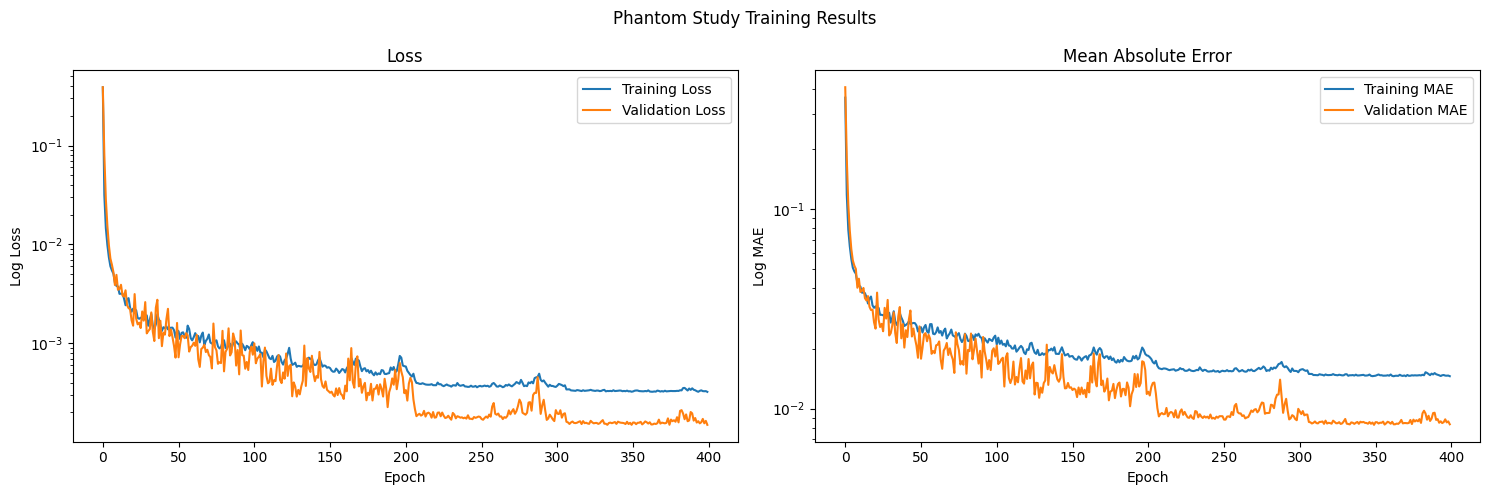

In [ ]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

2025-03-21 19:49:17,058 - DeepSSFP - INFO - Making predictions on data with shape (40, 128, 128, 4)
2025-03-21 19:49:17,478 - DeepSSFP - INFO - Predictions complete. Output shape: (40, 128, 128, 2)


Selected indices: [ 3 34]
Figure size: (8, 4)
Image visualization saved to D:/DeepSSFP/block_phantom_bandremoval_2_prediction_results.png


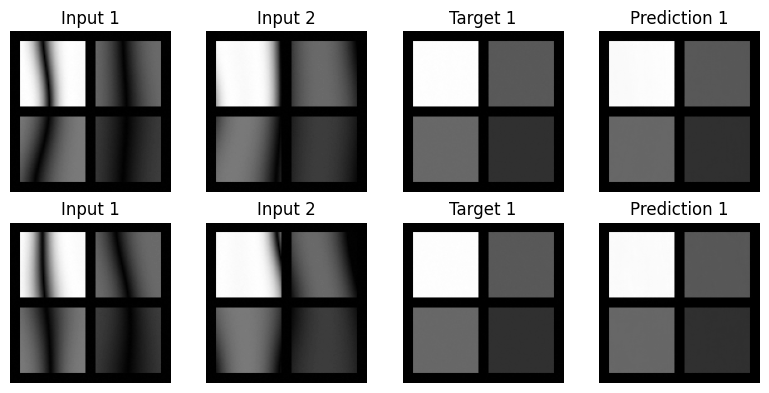

In [10]:
ds = deepssfp.Dataset(mode, input_data=data)
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.outputScaler.inverse_transform(deepssfp.predict(model, ds.x_test))

deepssfp.visualize_images(
    input_images=x_test,
    target_images=y_test,
    predicted_images=predictions,
    num_samples=2,
    save_path=f"{path}_prediction_results.png"
)

(40, 128, 128) (40, 128, 128)


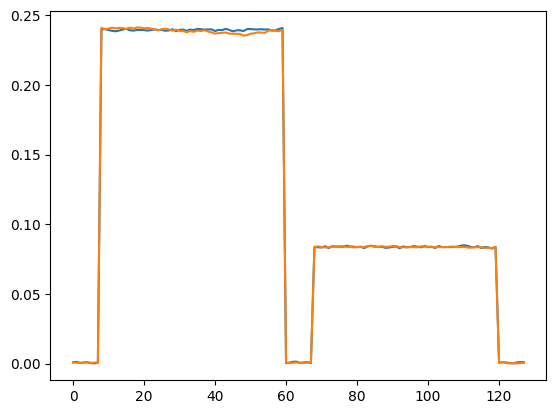

Target shape: (40, 128, 128)
Prediction shape: (40, 128, 128)
Segmentation shape: (128, 128)
Unique segmentation IDs: [0. 1. 2. 3. 4.]
IDs to plot: [1. 2. 3. 4.]
Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_2_metrics_scatter


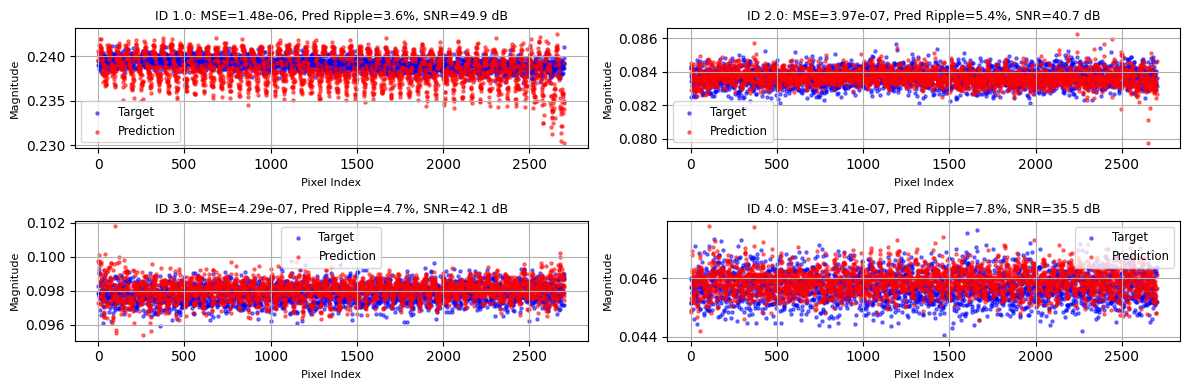

Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_2_metrics


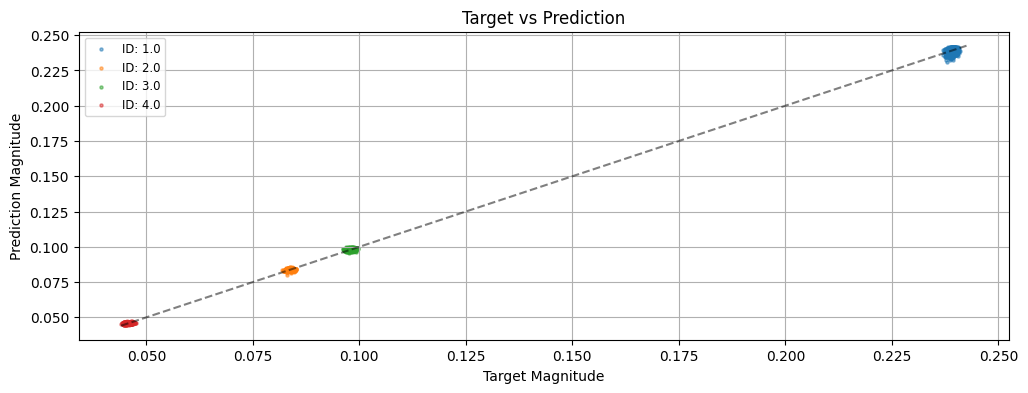


Metrics by Segment ID (averaged across all samples):
ID 1.0: MSE=1.48e-06, MAE=9.48e-04, Pred Min=0.2351, Pred Max=0.2437, Pred Ripple=3.61%, Pred SNR=49.9 dB, Target Min=0.2374, Target Max=0.2414, Target Ripple=1.67%, Target SNR=50.4 dB, Samples=40, Pixels=2704
ID 2.0: MSE=3.97e-07, MAE=4.94e-04, Pred Min=0.0813, Pred Max=0.0858, Pred Ripple=5.41%, Pred SNR=40.7 dB, Target Min=0.0819, Target Max=0.0854, Target Ripple=4.25%, Target SNR=41.3 dB, Samples=40, Pixels=2704
ID 3.0: MSE=4.29e-07, MAE=5.14e-04, Pred Min=0.0958, Pred Max=0.1003, Pred Ripple=4.67%, Pred SNR=42.1 dB, Target Min=0.0962, Target Max=0.0998, Target Ripple=3.67%, Target SNR=42.7 dB, Samples=40, Pixels=2704
ID 4.0: MSE=3.41e-07, MAE=4.62e-04, Pred Min=0.0440, Pred Max=0.0476, Pred Ripple=7.83%, Pred SNR=35.5 dB, Target Min=0.0439, Target Max=0.0475, Target Ripple=7.91%, Target SNR=36.1 dB, Samples=40, Pixels=2704
{1.0: {'mse': 1.4843476769501652e-06, 'mae': 0.0009476230576782347, 'pred_min': 0.23508906, 'pred_max': 0.

In [ ]:
pred = deepssfp.from_pairs_to_complex(predictions)
target = deepssfp.from_pairs_to_complex(y_test)
print(target.shape, pred.shape)

plt.plot(np.abs(target[0,20,:]))
plt.plot(np.abs(pred[0,20,:]))
plt.show()

metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics")
print(metrics)